# FullSubNet Loss Function Ablation Study - Multi-Experiment Runner

## Research Objective

Systematically compare loss functions for speech enhancement to determine which best balances:
1. Perceptual quality (PESQ)
2. Intelligibility (STOI)  
3. Signal quality (SI-SNR)
4. Generalization to unseen noise

## Loss Functions Compared

1. **Magnitude L1** - L1 loss on STFT magnitude
2. **Magnitude MSE** - MSE loss on STFT magnitude
3. **Waveform L1** - L1 loss on waveform
4. **SI-SNR** - Waveform domain SI-SNR as a loss function
5. **Magnitude L1 + SI-SNR** - Hybrid spectral/temporal
6. **Complex MSE** - MSE on real + imaginary STFT

## Experiment Design

- **Fixed**: Architecture, dataset, training procedure
- **Variable**: Loss function only
- **Metrics**: PESQ, STOI, SI-SNR + generalization gaps
- **Automation**: Run all experiments sequentially from config list

## Setup and Imports

In [1]:
import os
import sys
import json
import random
import yaml
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime
from typing import Dict, List, Tuple

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from tqdm.notebook import tqdm

# Setup paths
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Project imports
from src.data.manifest import load_manifest
from src.data.dataset import FullSubNetDataset
from src.models.fullsubnet import FullSubNet
from src.evaluation.evaluate import evaluate_model
from src.evaluation.metrics import validate_with_metrics
from src.training.losses import build_loss

print("✓ All imports successful")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

✓ Dataset classes defined
✓ Loss functions defined
✓ All imports successful
PyTorch version: 2.10.0+cu128
CUDA available: True


## Configuration: List All Experiments to Run

**Add/remove config files here to control which experiments run:**

In [ ]:
# ============================================================================
# EXPERIMENT CONFIGURATION - Edit this list to run different experiments
# ============================================================================

CONFIG_FILES = [
    "configs/loss_ablations/fullsubnet_mag_l1.yaml",
    "configs/loss_ablations/fullsubnet_mag_mse.yaml",
    "configs/loss_ablations/fullsubnet_wav_l1.yaml",
    "configs/loss_ablations/fullsubnet_sisnr.yaml",
    "configs/loss_ablations/fullsubnet_mag_l1_sisnr.yaml",
    "configs/loss_ablations/fullsubnet_complex_mse.yaml",
]

# Optional: Skip experiments if they already completed
SKIP_COMPLETED = True

# Device selection
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

print(f"Device: {DEVICE}")
print(f"\nExperiments to run: {len(CONFIG_FILES)}")
for i, config_file in enumerate(CONFIG_FILES, 1):
    print(f"  {i}. {config_file}")

Device: cuda

Experiments to run: 6
  1. configs/fullsubnet_mag_l1.yaml
  2. configs/fullsubnet_mag_mse.yaml
  3. configs/fullsubnet_wav_l1.yaml
  4. configs/fullsubnet_sisnr.yaml
  5. configs/fullsubnet_mag_l1_sisnr.yaml
  6. configs/fullsubnet_complex_mse.yaml


## Utility Functions

In [3]:
def set_seed(seed: int):
    """Set all random seeds for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def load_config(config_path: str) -> Dict:
    """Load experiment configuration from YAML."""
    with open(PROJECT_ROOT / config_path, 'r') as f:
        config = yaml.safe_load(f)
    return config


def setup_experiment_dirs(config: Dict) -> Tuple[Path, Path, Path]:
    """Create experiment directories."""
    PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
    results_root = PROJECT_ROOT / "results" / "fullsubnet_loss_ablation"
    results_dir = results_root / config['experiment_name']
    checkpoint_dir = results_dir / "checkpoints"
    plots_dir = PROJECT_ROOT / "plots" / "loss_ablation" / config['experiment_name']
    
    results_dir.mkdir(parents=True, exist_ok=True)
    checkpoint_dir.mkdir(parents=True, exist_ok=True)
    plots_dir.mkdir(parents=True, exist_ok=True)
    
    return results_dir, checkpoint_dir, plots_dir


def is_experiment_complete(results_dir: Path) -> bool:
    """Check if experiment already completed."""
    return (results_dir / 'evaluation_results.json').exists()


def save_config(config: Dict, save_path: Path):
    """Save configuration to file."""
    with open(save_path, 'w') as f:
        yaml.dump(config, f, default_flow_style=False, sort_keys=False)


def clear_gpu_memory():
    """Best-effort cleanup for low-VRAM experiments."""
    import gc
    gc.collect()
    if torch.cuda.is_available():
        try:
            torch.cuda.synchronize()
        except Exception:
            pass
        torch.cuda.empty_cache()


print("✓ Utility functions defined")

✓ Utility functions defined


## Dataset Loading (Shared Across Experiments)

In [4]:
def create_datasets(manifest_dict: Dict, config: Dict, device: torch.device) -> Dict:
    """Create all datasets for an experiment."""
    
    data_cfg = config['data']
    snr_range = tuple(data_cfg['snr_range'])
    aug_factor = data_cfg['augmentation_factor']
    eval_pairs = data_cfg.get('eval_pairs', 1)
    seed = config['seed']
    
    print(f"  Creating datasets (SNR: {snr_range}, Aug: {aug_factor}x)")
    
    datasets = {}
    
    # Training
    datasets['train'] = FullSubNetDataset(
        clean_files=manifest_dict['train'],
        noise_files=manifest_dict['noise_seen'],
        mode='train',
        snr_range=snr_range,
        augmentation_factor=aug_factor,
        base_seed=seed,
        epoch=0
    )
    
    # Validation (seen)
    datasets['val_seen'] = FullSubNetDataset(
        clean_files=manifest_dict['val'],
        noise_files=manifest_dict['noise_seen'],
        mode='val',
        snr_range=snr_range,
        eval_pairs_per_clean=eval_pairs,
        base_seed=seed 
    )
    
    # Validation (unseen)
    datasets['val_unseen'] = FullSubNetDataset(
        clean_files=manifest_dict['val'],
        noise_files=manifest_dict['noise_unseen'],
        mode='val',
        snr_range=snr_range,
        eval_pairs_per_clean=eval_pairs,
        base_seed=seed + 1
    )
    
    # Test (seen)
    datasets['test_seen'] = FullSubNetDataset(
        clean_files=manifest_dict['test'],
        noise_files=manifest_dict['noise_seen'],
        mode='test',
        snr_range=snr_range,
        eval_pairs_per_clean=eval_pairs,
        base_seed=seed + 2
    )
    
    # Test (unseen)
    datasets['test_unseen'] = FullSubNetDataset(
        clean_files=manifest_dict['test'],
        noise_files=manifest_dict['noise_unseen'],
        mode='test',
        snr_range=snr_range,
        eval_pairs_per_clean=eval_pairs,
        base_seed=seed + 3
    )
    
    print(f"  ✓ Datasets created: {sum(len(d) for d in datasets.values())} total pairs")
    
    return datasets


def create_dataloaders(datasets: Dict, batch_size: int) -> Dict:
    """Create dataloaders from datasets."""
    loaders = {}
    
    loaders['train'] = DataLoader(datasets['train'], batch_size=batch_size, shuffle=True, num_workers=0)
    loaders['val_seen'] = DataLoader(datasets['val_seen'], batch_size=batch_size, shuffle=False, num_workers=0)
    loaders['val_unseen'] = DataLoader(datasets['val_unseen'], batch_size=batch_size, shuffle=False, num_workers=0)
    loaders['test_seen'] = DataLoader(datasets['test_seen'], batch_size=batch_size, shuffle=False, num_workers=0)
    loaders['test_unseen'] = DataLoader(datasets['test_unseen'], batch_size=batch_size, shuffle=False, num_workers=0)
    
    return loaders

print("✓ Dataset functions defined")

✓ Dataset functions defined


## Model Creation

In [5]:
def create_model(config: Dict, device: torch.device) -> nn.Module:
    """Create FullSubNet model from config."""
    model_cfg = config['model']
    
    model = FullSubNet(
        n_fft=model_cfg['n_fft'],
        hop_length=model_cfg['hop_length'],
        win_length=model_cfg['win_length'],
        num_freqs=model_cfg['num_freqs'],
        freq_cutoffs=model_cfg['freq_cutoffs'],
        sb_num_center_freqs=model_cfg['sb_num_center_freqs'],
        sb_num_neighbor_freqs=model_cfg['sb_num_neighbor_freqs'],
        fb_num_center_freqs=model_cfg['fb_num_center_freqs'],
        fb_num_neighbor_freqs=model_cfg['fb_num_neighbor_freqs'],
        fb_hidden_size=model_cfg.get('fb_hidden_size', 512),
        sb_hidden_size=model_cfg.get('sb_hidden_size', 384)
    ).to(device)
    
    total_params = sum(p.numel() for p in model.parameters())
    print(f"  Model created: {total_params:,} parameters")
    
    return model

print("✓ Model creation function defined")

✓ Model creation function defined


## Training Functions

In [6]:
def train_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    total_loss = 0
    
    pbar = tqdm(loader, desc="Training", leave=False)
    for batch in pbar:
        noisy = batch['noisy'].to(device)
        clean = batch['clean'].to(device)
        
        enhanced = model(noisy)
        loss = criterion(enhanced, clean)
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        
        total_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.6f}'})
    
    return total_loss / len(loader)


def initialize_history() -> Dict:
    """Initialize training history dictionary."""
    return {
        'train_loss': [],
        'val_seen_loss': [],
        'val_unseen_loss': [],
        'val_seen_pesq': [],
        'val_unseen_pesq': [],
        'val_seen_stoi': [],
        'val_unseen_stoi': [],
        'val_seen_si_snr': [],
        'val_unseen_si_snr': [],
        'generalization_gap_pesq': [],
        'generalization_gap_stoi': [],
        'generalization_gap_si_snr': [],
        'lr': []
    }


def run_training(model, loaders, datasets, criterion, optimizer, scheduler,
                config, checkpoint_dir, device):
    """Run complete training loop."""
    
    history = initialize_history()
    best_val_loss = float('inf')
    epochs_without_improvement = 0
    
    num_epochs = config['training']['epochs']
    patience = config['training'].get('patience', 10)
    
    print(f"\n  Training for {num_epochs} epochs (patience={patience})")
    print("  " + "="*60)
    
    for epoch in range(1, num_epochs + 1):
        print(f"\n  Epoch {epoch}/{num_epochs}", end=" ")
        
        # Update dataset epoch
        datasets['train'].set_epoch(epoch)
        
        # Train
        train_loss = train_epoch(model, loaders['train'], criterion, optimizer, device)
        
        # Validate
        val_seen_metrics = validate_with_metrics(
            model, loaders['val_seen'], criterion, device, max_pesq_samples=50
        )
        val_unseen_metrics = validate_with_metrics(
            model, loaders['val_unseen'], criterion, device, max_pesq_samples=50
        )
        
        # Scheduler
        scheduler.step(val_seen_metrics['loss'])
        current_lr = optimizer.param_groups[0]['lr']
        
        # Compute gaps
        gap_pesq = val_seen_metrics['pesq'] - val_unseen_metrics['pesq']
        gap_stoi = val_seen_metrics['stoi'] - val_unseen_metrics['stoi']
        gap_si_snr = val_seen_metrics['si_snr'] - val_unseen_metrics['si_snr']
        
        # Log
        history['train_loss'].append(train_loss)
        history['val_seen_loss'].append(val_seen_metrics['loss'])
        history['val_unseen_loss'].append(val_unseen_metrics['loss'])
        history['val_seen_pesq'].append(val_seen_metrics['pesq'])
        history['val_unseen_pesq'].append(val_unseen_metrics['pesq'])
        history['val_seen_stoi'].append(val_seen_metrics['stoi'])
        history['val_unseen_stoi'].append(val_unseen_metrics['stoi'])
        history['val_seen_si_snr'].append(val_seen_metrics['si_snr'])
        history['val_unseen_si_snr'].append(val_unseen_metrics['si_snr'])
        history['generalization_gap_pesq'].append(gap_pesq)
        history['generalization_gap_stoi'].append(gap_stoi)
        history['generalization_gap_si_snr'].append(gap_si_snr)
        history['lr'].append(current_lr)
        
        # Print compact summary
        print(f"| Loss: {train_loss:.4f} | PESQ: {val_seen_metrics['pesq']:.2f}/{val_unseen_metrics['pesq']:.2f} | "
              f"STOI: {val_seen_metrics['stoi']:.2f}/{val_unseen_metrics['stoi']:.2f} | "
              f"SI-SNR: {val_seen_metrics['si_snr']:.1f}/{val_unseen_metrics['si_snr']:.1f}", end="")
        
        # Save best
        if val_seen_metrics['loss'] < best_val_loss:
            best_val_loss = val_seen_metrics['loss']
            epochs_without_improvement = 0
            
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict() if scheduler else None,
                'best_val_loss': best_val_loss,
                'history': history,
                'config': config
            }, checkpoint_dir / 'best_model.pth')
            print(" ✓", end="")
        else:
            epochs_without_improvement += 1
        
        # Early stopping
        if epochs_without_improvement >= patience:
            print(f"\n\n  Early stopping after {epoch} epochs")
            break
    
    print(f"\n\n  ✓ Training complete! Best val loss: {best_val_loss:.6f}")
    return history, best_val_loss

print("✓ Training functions defined")

✓ Training functions defined


## Evaluation Functions

In [7]:
def run_final_evaluation(model, loaders, checkpoint_dir, results_dir, device):
    """Run final evaluation on test sets."""
    
    # Load best model
    checkpoint = torch.load(checkpoint_dir / 'best_model.pth', map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    
    print("\n  Evaluating on test sets...")
    
    # Evaluate
    evaluate_model(model, loaders['test_seen'], loaders['test_unseen'], results_dir, device)

print("✓ Evaluation functions defined")

✓ Evaluation functions defined


## Visualization Functions

In [8]:
def plot_training_curves(history: Dict, plots_dir: Path, exp_name: str):
    """Plot training curves with SI-SNR included."""
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    epochs = range(1, len(history['train_loss']) + 1)
    
    # Plot 1: Loss
    axes[0, 0].plot(epochs, history['train_loss'], label='Train', linewidth=2)
    axes[0, 0].plot(epochs, history['val_seen_loss'], label='Val (Seen)', linewidth=2)
    axes[0, 0].plot(epochs, history['val_unseen_loss'], label='Val (Unseen)', linewidth=2)
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Training and Validation Loss', fontweight='bold')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Plot 2: PESQ
    axes[0, 1].plot(epochs, history['val_seen_pesq'], label='Seen', linewidth=2)
    axes[0, 1].plot(epochs, history['val_unseen_pesq'], label='Unseen', linewidth=2)
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('PESQ')
    axes[0, 1].set_title('PESQ (Perceptual Quality)', fontweight='bold')
    axes[0, 1].set_ylim([0, 4.5])
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Plot 3: STOI
    axes[0, 2].plot(epochs, history['val_seen_stoi'], label='Seen', linewidth=2)
    axes[0, 2].plot(epochs, history['val_unseen_stoi'], label='Unseen', linewidth=2)
    axes[0, 2].set_xlabel('Epoch')
    axes[0, 2].set_ylabel('STOI')
    axes[0, 2].set_title('STOI (Intelligibility)', fontweight='bold')
    axes[0, 2].set_ylim([0, 1])
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)
    
    # Plot 4: SI-SNR
    axes[1, 0].plot(epochs, history['val_seen_si_snr'], label='Seen', linewidth=2)
    axes[1, 0].plot(epochs, history['val_unseen_si_snr'], label='Unseen', linewidth=2)
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('SI-SNR (dB)')
    axes[1, 0].set_title('SI-SNR (Signal Quality)', fontweight='bold')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Plot 5: Generalization Gaps (PESQ + STOI)
    axes[1, 1].plot(epochs, history['generalization_gap_pesq'], label='PESQ Gap', linewidth=2, color='purple')
    axes[1, 1].plot(epochs, history['generalization_gap_stoi'], label='STOI Gap', linewidth=2, color='orange')
    axes[1, 1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Gap (Seen - Unseen)')
    axes[1, 1].set_title('Generalization Gap (PESQ & STOI)', fontweight='bold')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    # Plot 6: SI-SNR Gap
    axes[1, 2].plot(epochs, history['generalization_gap_si_snr'], label='SI-SNR Gap', linewidth=2, color='green')
    axes[1, 2].axhline(y=0, color='black', linestyle='--', alpha=0.5)
    axes[1, 2].set_xlabel('Epoch')
    axes[1, 2].set_ylabel('Gap (dB)')
    axes[1, 2].set_title('Generalization Gap (SI-SNR)', fontweight='bold')
    axes[1, 2].legend()
    axes[1, 2].grid(True, alpha=0.3)
    
    plt.suptitle(f'{exp_name} - Training Curves', fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.savefig(plots_dir / 'training_curves.png', dpi=150, bbox_inches='tight')
    plt.close()

print("✓ Visualization functions defined")

✓ Visualization functions defined


## Main Experiment Runner

In [9]:
def run_single_experiment(config_file: str, manifest_dict: Dict, device: torch.device):
    """Run a single experiment from config file."""

    config = None
    datasets = None
    loaders = None
    model = None
    criterion = None
    optimizer = None
    scheduler = None
    history = None
    evaluation_summary = None

    clear_gpu_memory()

    try:
        # Load config
        config = load_config(config_file)
        exp_name = config['experiment_name']

        print(f"\n{'='*70}")
        print(f"EXPERIMENT: {exp_name}")
        print(f"Loss: {config['loss']['name']}")
        print(f"{'='*70}")

        # Setup
        set_seed(config['seed'])
        results_dir, checkpoint_dir, plots_dir = setup_experiment_dirs(config)

        # Check if already complete
        if SKIP_COMPLETED and is_experiment_complete(results_dir):
            print(f"  ⊙ Experiment already completed, skipping...")
            return

        # Save config
        save_config(config, results_dir / 'config.yaml')

        # Create datasets and loaders
        datasets = create_datasets(manifest_dict, config, device)
        loaders = create_dataloaders(datasets, config['training']['batch_size'])

        # Create model
        model = create_model(config, device)

        # Create loss, optimizer, scheduler
        criterion = build_loss(config)
        optimizer = torch.optim.AdamW(model.parameters(), lr=config['training']['learning_rate'], weight_decay=config['training'].get('weight_decay', 1e-5))
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=5
        )

        # Train
        history, best_val_loss = run_training(
            model, loaders, datasets, criterion, optimizer, scheduler,
            config, checkpoint_dir, device
        )

        # Save history
        with open(results_dir / 'training_history.json', 'w') as f:
            json.dump(history, f, indent=2)

        # Evaluate
        run_final_evaluation(model, loaders, checkpoint_dir, results_dir, device)

        # # Save evaluation results
        # evaluation_summary['experiment_name'] = exp_name
        # evaluation_summary['loss_function'] = config['loss']['name']
        # evaluation_summary['best_val_loss'] = best_val_loss

        # with open(results_dir / 'evaluation_results.json', 'w') as f:
        #     json.dump(evaluation_summary, f, indent=2)

        # Plot
        plot_training_curves(history, plots_dir, exp_name)

        print(f"\n  ✓ Experiment complete! Results saved to {results_dir}")
        print(f"  {'='*70}\n")

    finally:
        # Best-effort cleanup for 8GB VRAM
        del evaluation_summary
        del history
        del scheduler
        del optimizer
        del criterion
        del model
        del loaders
        del datasets
        clear_gpu_memory()

print("✓ Experiment runner defined")


✓ Experiment runner defined


## Load Shared Resources (Manifest)

In [10]:
# Load manifest once (shared across all experiments)
MANIFEST_PATH = "data/MANIFEST.json"

print("Loading manifest...")
manifest_dict = load_manifest(MANIFEST_PATH)

print(f"✓ Manifest loaded:")
print(f"  Train: {len(manifest_dict['train'])} files")
print(f"  Val: {len(manifest_dict['val'])} files")
print(f"  Test: {len(manifest_dict['test'])} files")
print(f"  Seen noise: {len(manifest_dict['noise_seen'])} files")
print(f"  Unseen noise: {len(manifest_dict['noise_unseen'])} files")

Loading manifest...
✓ Manifest loaded:
  Train: 160 files
  Val: 20 files
  Test: 20 files
  Seen noise: 38 files
  Unseen noise: 22 files


## Run All Experiments

This cell will run all experiments in `CONFIG_FILES` sequentially.

In [11]:
print("\n" + "#"*70)
print("# RUNNING ALL EXPERIMENTS")
print("#"*70)
print(f"\nTotal experiments: {len(CONFIG_FILES)}")
print(f"Device: {DEVICE}")
print(f"Skip completed: {SKIP_COMPLETED}")

start_time = datetime.now()

for i, config_file in enumerate(CONFIG_FILES, 1):
    print(f"\n\n{'#'*70}")
    print(f"# EXPERIMENT {i}/{len(CONFIG_FILES)}: {Path(config_file).stem}")
    print(f"{'#'*70}")

    clear_gpu_memory()
    try:
        run_single_experiment(config_file, manifest_dict, DEVICE)
    except Exception as e:
        print(f"\n  ❌ Experiment failed with error: {e}")
        print(f"  Continuing to next experiment...\n")
    finally:
        clear_gpu_memory()

end_time = datetime.now()
duration = end_time - start_time

print("\n\n" + "#"*70)
print("# ALL EXPERIMENTS COMPLETE")
print("#"*70)
print(f"\nTotal time: {duration}")
print(f"Results saved to: results/fullsubnet_loss_ablation/")



######################################################################
# RUNNING ALL EXPERIMENTS
######################################################################

Total experiments: 6
Device: cuda
Skip completed: True


######################################################################
# EXPERIMENT 1/6: fullsubnet_mag_l1
######################################################################

EXPERIMENT: fullsubnet_mag_l1
Loss: mag_l1
  Creating datasets (SNR: (-5, 20), Aug: 5x)
[FullSubNet-TRAIN] Loading 160 clean files...
[FullSubNet-TRAIN] Loading 38 noise files...
[FullSubNet-TRAIN] 285 clean segments, 76 noise segments
[FullSubNet-TRAIN] Initial train SNR range: (-5, 20)
[FullSubNet-VAL] Loading 20 clean files...
[FullSubNet-VAL] Loading 38 noise files...
[FullSubNet-VAL] 36 clean segments, 76 noise segments
[FullSubNet-VAL] Generating deterministic fixed pairs (eval_pairs_per_clean=3)...
[FullSubNet-VAL] Total fixed pairs: 108
[FullSubNet-VAL] Loading 20 clean files...


Training:   0%|          | 0/179 [00:00<?, ?it/s]

| Loss: 0.0392 | PESQ: 2.27/2.16 | STOI: 0.88/0.90 | SI-SNR: -9.5/-8.3 ✓
  Epoch 2/50 

Training:   0%|          | 0/179 [00:00<?, ?it/s]

| Loss: 0.0229 | PESQ: 2.35/2.18 | STOI: 0.90/0.90 | SI-SNR: -7.5/-11.3 ✓
  Epoch 3/50 

...

| Loss: 0.0049 | PESQ: 2.93/2.59 | STOI: 0.94/0.93 | SI-SNR: 18.3/14.6 ✓

  ✓ Training complete! Best val loss: 0.009710

  Evaluating on test sets...
Evaluating Model

Evaluating on SEEN noise types...


Test (Seen): 100%|██████████| 13/13 [00:07<00:00,  1.63it/s]



Evaluating on UNSEEN noise types...


Test (Unseen): 100%|██████████| 13/13 [00:07<00:00,  1.66it/s]



Results Summary

SEEN Noise Types:
  MSE:  0.000032
  PESQ: 2.973 ± 0.881
  STOI: 0.931 ± 0.086
  SI-SNR: 18.568 ± 6.343

UNSEEN Noise Types:
  MSE:  0.000123
  PESQ: 2.443 ± 0.829
  STOI: 0.898 ± 0.106
  SI-SNR: 13.580 ± 6.822

Generalization Gap:
  PESQ: 0.530
  STOI: 0.033
  SI-SNR: 4.988

✓ Results saved to /home/paul/Desktop/projects/clarity-net/results/fullsubnet_loss_ablation/fullsubnet_complex_mse/evaluation_results.json

  ✓ Experiment complete! Results saved to /home/paul/Desktop/projects/clarity-net/results/fullsubnet_loss_ablation/fullsubnet_complex_mse



######################################################################
# ALL EXPERIMENTS COMPLETE
######################################################################

Total time: 7:22:55.196824
Results saved to: results/fullsubnet_loss_ablation/


## Compare All Results

After all experiments complete, create comparison visualizations.

In [34]:
def load_all_results() -> pd.DataFrame:
    """Load all experiment results into a DataFrame."""
    
    results_root = Path("../results/fullsubnet_loss_ablation")
    all_results = []

    experiment_to_loss_mapping = {
        "fullsubnet_mag_l1": "Magnitude L1",
        "fullsubnet_mag_mse": "Magnitude MSE",
        "fullsubnet_wav_l1": "Waveform L1",
        "fullsubnet_sisnr": "SI-SNR",
        "fullsubnet_mag_l1_sisnr": "Mag L1 + SI-SNR",
        "fullsubnet_complex_mse": "Complex MSE"
    }
    
    for exp_dir in results_root.iterdir():
        if not exp_dir.is_dir():
            continue
        
        eval_file = exp_dir / 'evaluation_results.json'
        if not eval_file.exists():
            continue
        
        with open(eval_file, 'r') as f:
            result = json.load(f)
        print(f"\nLoaded results for {exp_dir.name}:")
        print(result)
        # Flatten for DataFrame
        row = {
            'experiment': result.get('experiment_name', exp_dir.name),
            'loss': experiment_to_loss_mapping.get(exp_dir.name, 'Unknown'),
            'seen_pesq': result['seen']['pesq_mean'],
            'unseen_pesq': result['unseen']['pesq_mean'],
            'seen_stoi': result['seen']['stoi_mean'],
            'unseen_stoi': result['unseen']['stoi_mean'],
            'seen_si_snr': result['seen']['si_snr_mean'],
            'unseen_si_snr': result['unseen']['si_snr_mean'],
            'gap_pesq': result['generalization_gap']['pesq'],
            'gap_stoi': result['generalization_gap']['stoi'],
            'gap_si_snr': result['generalization_gap']['si_snr'],
        }
        all_results.append(row)
    
    return pd.DataFrame(all_results)


# Load and display results
results_df = load_all_results()

if len(results_df) == 0:
    print("No results found yet. Run experiments first.")
else:
    print("\n" + "="*80)
    print("COMPARISON OF ALL EXPERIMENTS")
    print("="*80)
    print()
    print(results_df.to_string(index=False))
    
    # Save to CSV
    results_df.to_csv('../results/fullsubnet_loss_ablation/comparison_summary.csv', index=False)
    print(f"\n✓ Summary saved to: ../results/fullsubnet_loss_ablation/comparison_summary.csv")


Loaded results for fullsubnet_mag_l1_sisnr:
{'seen': {'mse': 0.0032829143635283867, 'pesq_mean': 2.3223446234308107, 'pesq_std': 0.9835034576644748, 'stoi_mean': 0.9013038105263163, 'stoi_std': 0.11338787703838886, 'si_snr_mean': 9.062759733862347, 'si_snr_std': 11.816890935786777}, 'unseen': {'mse': 0.0032304782160701086, 'pesq_mean': 2.090729478633765, 'pesq_std': 0.7882295287968345, 'stoi_mean': 0.8718125741053679, 'stoi_std': 0.12527976092342308, 'si_snr_mean': 8.020394375002143, 'si_snr_std': 8.759532286933881}, 'generalization_gap': {'pesq': 0.2316151447970456, 'stoi': 0.029491236420948308, 'si_snr': 1.042365358860204}}

Loaded results for fullsubnet_mag_mse:
{'seen': {'mse': 0.002860884332151797, 'pesq_mean': 2.935948231003501, 'pesq_std': 0.8572495218065136, 'stoi_mean': 0.9291682120337562, 'stoi_std': 0.08342824279308605, 'si_snr_mean': -6.996178452264179, 'si_snr_std': 14.455645605942603}, 'unseen': {'mse': 0.0029835838806600524, 'pesq_mean': 2.4426394472218522, 'pesq_std': 

In [37]:
results_df

,experiment,loss,seen_pesq,unseen_pesq,seen_stoi,unseen_stoi,seen_si_snr,unseen_si_snr,gap_pesq,gap_stoi,gap_si_snr
0,fullsubnet_mag_l1_sisnr,Mag L1 + SI-SNR,2.322345,2.090729,0.901304,0.871813,9.062760,8.020394,0.231615,0.029491,1.042365
1,fullsubnet_mag_mse,Magnitude MSE,2.935948,2.442639,0.929168,0.901844,-6.996178,-7.410830,0.493309,0.027324,0.414652
2,fullsubnet_wav_l1,Waveform L1,3.082360,2.487679,0.940531,0.908001,20.576546,14.033728,0.594682,0.032530,6.542818
3,fullsubnet_complex_mse,Complex MSE,2.972982,2.442930,0.931228,0.898369,18.567852,13.580176,0.530052,0.032859,4.987676
4,fullsubnet_sisnr,SI-SNR,3.056153,2.481904,0.933178,0.902325,19.662334,13.852020,0.574249,0.030852,5.810314
5,fullsubnet_mag_l1,Magnitude L1,3.209823,2.531438,0.942794,0.908453,-7.822604,-7.485150,0.678385,0.034341,-0.337454


## Comparison Visualization

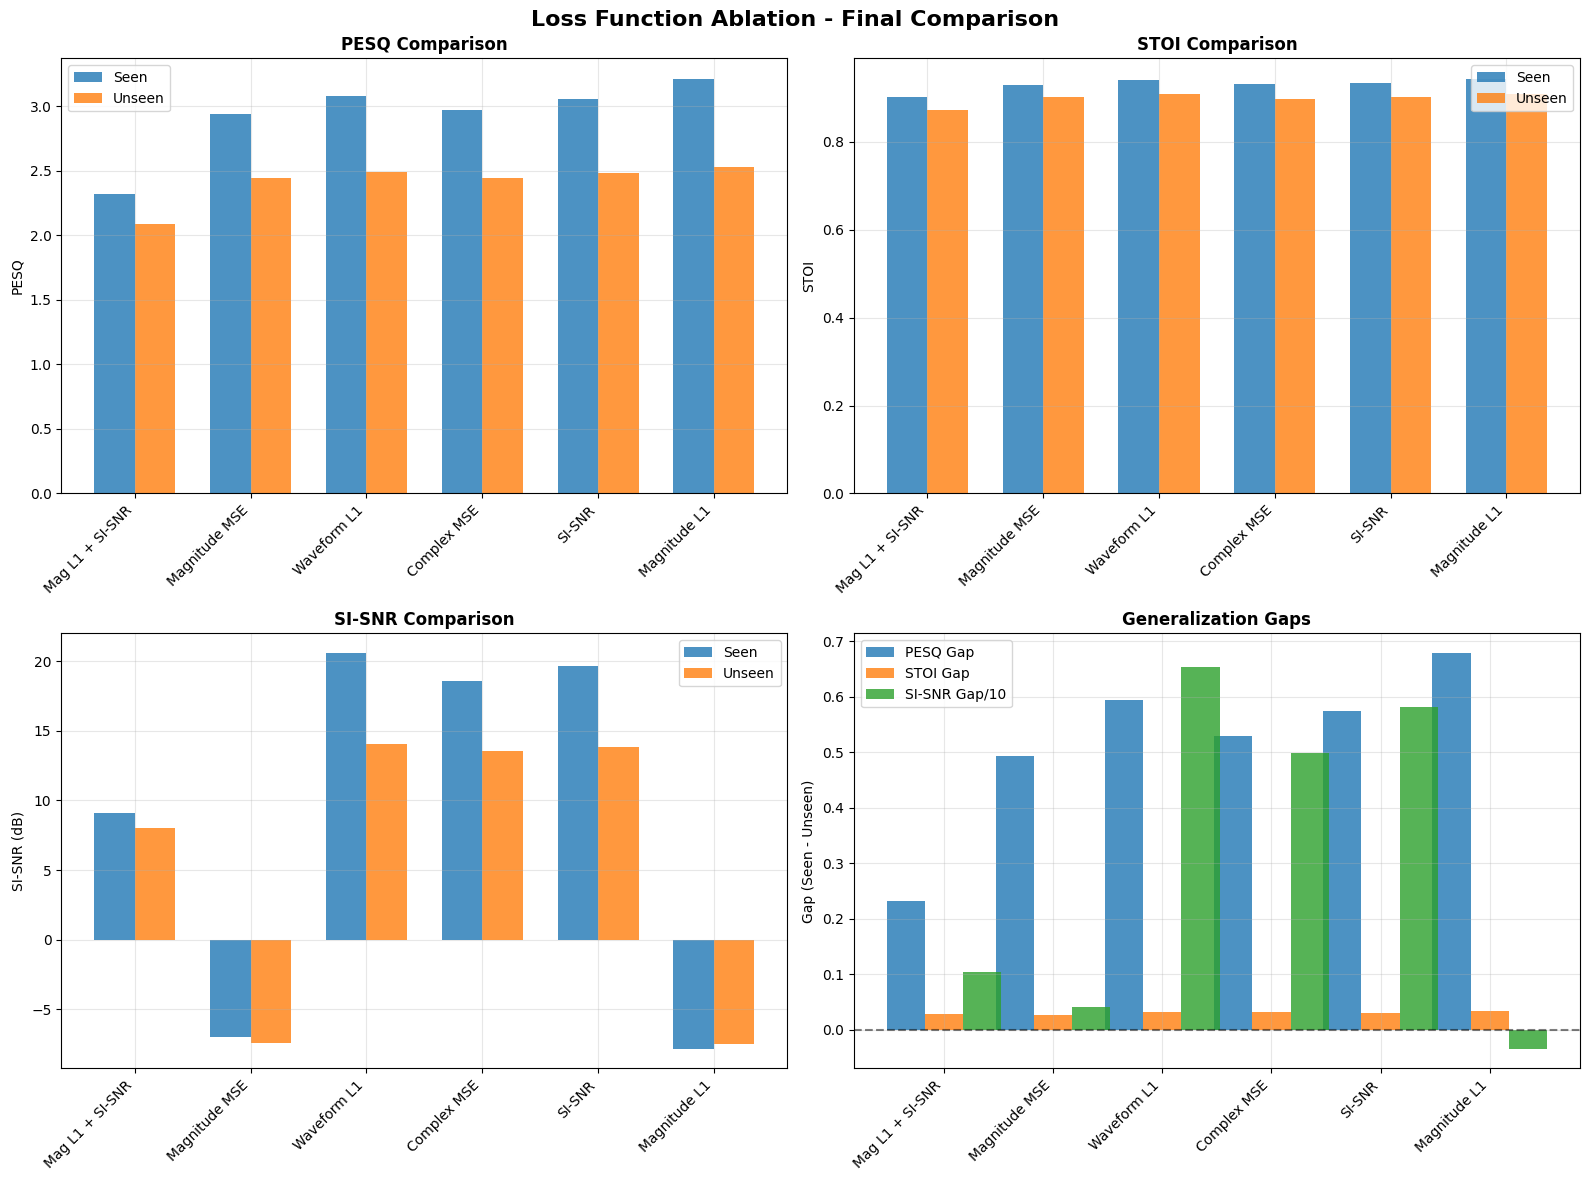


✓ Comparison plot saved to: ../plots/loss_ablation/comparison_plot.png


In [35]:
if len(results_df) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Plot 1: PESQ Comparison
    x = np.arange(len(results_df))
    width = 0.35
    axes[0, 0].bar(x - width/2, results_df['seen_pesq'], width, label='Seen', alpha=0.8)
    axes[0, 0].bar(x + width/2, results_df['unseen_pesq'], width, label='Unseen', alpha=0.8)
    axes[0, 0].set_ylabel('PESQ')
    axes[0, 0].set_title('PESQ Comparison', fontweight='bold')
    axes[0, 0].set_xticks(x)
    axes[0, 0].set_xticklabels(results_df['loss'], rotation=45, ha='right')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Plot 2: STOI Comparison
    axes[0, 1].bar(x - width/2, results_df['seen_stoi'], width, label='Seen', alpha=0.8)
    axes[0, 1].bar(x + width/2, results_df['unseen_stoi'], width, label='Unseen', alpha=0.8)
    axes[0, 1].set_ylabel('STOI')
    axes[0, 1].set_title('STOI Comparison', fontweight='bold')
    axes[0, 1].set_xticks(x)
    axes[0, 1].set_xticklabels(results_df['loss'], rotation=45, ha='right')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Plot 3: SI-SNR Comparison
    axes[1, 0].bar(x - width/2, results_df['seen_si_snr'], width, label='Seen', alpha=0.8)
    axes[1, 0].bar(x + width/2, results_df['unseen_si_snr'], width, label='Unseen', alpha=0.8)
    axes[1, 0].set_ylabel('SI-SNR (dB)')
    axes[1, 0].set_title('SI-SNR Comparison', fontweight='bold')
    axes[1, 0].set_xticks(x)
    axes[1, 0].set_xticklabels(results_df['loss'], rotation=45, ha='right')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Plot 4: Generalization Gaps
    axes[1, 1].bar(x - width, results_df['gap_pesq'], width, label='PESQ Gap', alpha=0.8)
    axes[1, 1].bar(x, results_df['gap_stoi'], width, label='STOI Gap', alpha=0.8)
    axes[1, 1].bar(x + width, results_df['gap_si_snr']/10, width, label='SI-SNR Gap/10', alpha=0.8)
    axes[1, 1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
    axes[1, 1].set_ylabel('Gap (Seen - Unseen)')
    axes[1, 1].set_title('Generalization Gaps', fontweight='bold')
    axes[1, 1].set_xticks(x)
    axes[1, 1].set_xticklabels(results_df['loss'], rotation=45, ha='right')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.suptitle('Loss Function Ablation - Final Comparison', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../plots/loss_ablation/comparison_plot.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\n✓ Comparison plot saved to: ../plots/loss_ablation/comparison_plot.png")

## Summary Statistics

In [36]:
if len(results_df) > 0:
    print("\n" + "="*80)
    print("BEST RESULTS BY METRIC")
    print("="*80)
    
    print(f"\nBest PESQ (Seen): {results_df.loc[results_df['seen_pesq'].idxmax(), 'loss']} "
          f"({results_df['seen_pesq'].max():.3f})")
    print(f"Best PESQ (Unseen): {results_df.loc[results_df['unseen_pesq'].idxmax(), 'loss']} "
          f"({results_df['unseen_pesq'].max():.3f})")
    
    print(f"\nBest STOI (Seen): {results_df.loc[results_df['seen_stoi'].idxmax(), 'loss']} "
          f"({results_df['seen_stoi'].max():.3f})")
    print(f"Best STOI (Unseen): {results_df.loc[results_df['unseen_stoi'].idxmax(), 'loss']} "
          f"({results_df['unseen_stoi'].max():.3f})")
    
    print(f"\nBest SI-SNR (Seen): {results_df.loc[results_df['seen_si_snr'].idxmax(), 'loss']} "
          f"({results_df['seen_si_snr'].max():.2f} dB)")
    print(f"Best SI-SNR (Unseen): {results_df.loc[results_df['unseen_si_snr'].idxmax(), 'loss']} "
          f"({results_df['unseen_si_snr'].max():.2f} dB)")
    
    print(f"\nSmallest PESQ Gap: {results_df.loc[results_df['gap_pesq'].abs().idxmin(), 'loss']} "
          f"({results_df['gap_pesq'].min():+.3f})")
    print(f"Smallest STOI Gap: {results_df.loc[results_df['gap_stoi'].abs().idxmin(), 'loss']} "
          f"({results_df['gap_stoi'].min():+.3f})")
    print(f"Smallest SI-SNR Gap: {results_df.loc[results_df['gap_si_snr'].abs().idxmin(), 'loss']} "
          f"({results_df['gap_si_snr'].min():+.2f} dB)")
    
    print("\n" + "="*80)


BEST RESULTS BY METRIC

Best PESQ (Seen): Magnitude L1 (3.210)
Best PESQ (Unseen): Magnitude L1 (2.531)

Best STOI (Seen): Magnitude L1 (0.943)
Best STOI (Unseen): Magnitude L1 (0.908)

Best SI-SNR (Seen): Waveform L1 (20.58 dB)
Best SI-SNR (Unseen): Waveform L1 (14.03 dB)

Smallest PESQ Gap: Mag L1 + SI-SNR (+0.232)
Smallest STOI Gap: Magnitude MSE (+0.027)
Smallest SI-SNR Gap: Magnitude L1 (-0.34 dB)

